In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [2]:
# Cargar el dataset, cambiar ruta dependiendo de tu ubicación
ruta = r"C:\Users\mejia\Desktop\Estudio\IA\Proyecto4-IA\Datos\data.csv"
df = pd.read_csv(ruta)

# Mostrar las primeras filas
df.head(5)


,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         800 non-null    int64  
 1   Height_cm                   800 non-null    int64  
 2   Weight_kg                   800 non-null    int64  
 3   Position                    800 non-null    object 
 4   Training_Hours_Per_Week     800 non-null    float64
 5   Matches_Played_Past_Season  800 non-null    int64  
 6   Previous_Injury_Count       800 non-null    int64  
 7   Knee_Strength_Score         800 non-null    float64
 8   Hamstring_Flexibility       800 non-null    float64
 9   Reaction_Time_ms            800 non-null    float64
 10  Balance_Test_Score          800 non-null    float64
 11  Sprint_Speed_10m_s          800 non-null    float64
 12  Agility_Score               800 non-null    float64
 13  Sleep_Hours_Per_Night       800 non

# 1. Limpieza de datos, eliminar o imputar datos faltantes, outliers, etc

In [4]:
# Contar valores faltantes por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Porcentaje de nulos
print("\nPorcentaje de valores nulos por variable:")
print((df.isnull().mean() * 100).round(2))

# Imputar o eliminar según el caso
# Ejemplo: imputar medias en variables numéricas
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Ejemplo: imputar moda en variables categóricas
for col in df.select_dtypes(exclude=np.number).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# =============================
# 3. DETECCIÓN DE OUTLIERS (Método IQR)
# =============================
def detectar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[columna] < lower) | (dataframe[columna] > upper)]
    return outliers

# Revisar cantidad de outliers por variable numérica
print("\nCantidad de outliers por variable:")
for col in df.select_dtypes(include=np.number).columns:
    cantidad = len(detectar_outliers_iqr(df, col))
    print(f"{col}: {cantidad}")

# =============================
# 4. TRATAMIENTO DE OUTLIERS
# =============================
# Opción 1: Winsorización (limitar valores extremos)
for col in df.select_dtypes(include=np.number).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# =============================
# 5. DUPLICADOS E INCONSISTENCIAS
# =============================
print("\nRegistros duplicados:", df.duplicated().sum())

# Eliminar duplicados si existen
df.drop_duplicates(inplace=True)

# =============================
# 6. VERIFICACIÓN FINAL
# =============================
print("\nVerificación final:")
print(df.describe())
print("\nValores nulos restantes:", df.isnull().sum().sum())


Valores nulos por columna:
Age                           0
Height_cm                     0
Weight_kg                     0
Position                      0
Training_Hours_Per_Week       0
Matches_Played_Past_Season    0
Previous_Injury_Count         0
Knee_Strength_Score           0
Hamstring_Flexibility         0
Reaction_Time_ms              0
Balance_Test_Score            0
Sprint_Speed_10m_s            0
Agility_Score                 0
Sleep_Hours_Per_Night         0
Stress_Level_Score            0
Nutrition_Quality_Score       0
Warmup_Routine_Adherence      0
Injury_Next_Season            0
BMI                           0
dtype: int64

Porcentaje de valores nulos por variable:
Age                           0.0
Height_cm                     0.0
Weight_kg                     0.0
Position                      0.0
Training_Hours_Per_Week       0.0
Matches_Played_Past_Season    0.0
Previous_Injury_Count         0.0
Knee_Strength_Score           0.0
Hamstring_Flexibility         0.0
Re

C:\Users\mejia\AppData\Local\Temp\ipykernel_5400\369553384.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\mejia\AppData\Local\Temp\ipykernel_5400\369553384.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

### Justificacion
#### Durante la etapa de limpieza de datos, se verificó la ausencia de valores faltantes en el conjunto de datos, por lo que no fue necesario aplicar imputaciones. Posteriormente, se identificaron valores atípicos en varias variables numéricas mediante el método del rango intercuartílico (IQR). Estos valores extremos fueron ajustados mediante el proceso de winsorización, con el fin de reducir su impacto sin eliminar información relevante. También se realizó una revisión de registros duplicados, sin encontrarse casos repetidos. Finalmente, se elaboró un resumen estadístico de las variables, confirmando que los datos presentan una distribución coherente y adecuada para continuar con las siguientes etapas del análisis.

# 2. Transformar todas las variables (características) en valores numéricos (usando one hot encoding, label encoding, binarización, discretización, etc)

#### Como se evidencio en el inicio, todas las variables son de tipo cuantitativas, solamente hay una varible categorica. La variable Position.

In [6]:
# Aplicar One Hot Encoding a la variable 'Position'
encoder = OneHotEncoder(sparse_output=False, drop='first')
position_encoded = encoder.fit_transform(df[['Position']].values)

# Obtener los nombres de las columnas codificadas
feature_names = encoder.get_feature_names_out(['Position'])

# Crear DataFrame con las columnas codificadas
position_df = pd.DataFrame(position_encoded, columns=feature_names)

# Combinar el DataFrame original con las columnas codificadas
df_encoded = pd.concat([df.drop('Position', axis=1), position_df], axis=1)

# Verificar resultado
print("Columnas después de One Hot Encoding:")
print(df_encoded.columns)

Columnas después de One Hot Encoding:
Index(['Age', 'Height_cm', 'Weight_kg', 'Training_Hours_Per_Week',
       'Matches_Played_Past_Season', 'Previous_Injury_Count',
       'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms',
       'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score',
       'Sleep_Hours_Per_Night', 'Stress_Level_Score',
       'Nutrition_Quality_Score', 'Warmup_Routine_Adherence',
       'Injury_Next_Season', 'BMI', 'Position_Forward', 'Position_Goalkeeper',
       'Position_Midfielder'],
      dtype='object')


### Justificacion
#### Se aplicó One Hot Encoding para transformar la variable categórica Position en formato numérico, permitiendo que los algoritmos de aprendizaje automático interpreten correctamente esta información. Este método evita asignar relaciones numéricas falsas entre categorías y garantiza que cada posición sea tratada de manera independiente dentro del modelo.

# 3. Realizar normalización (Scaler)

In [7]:
y = df_encoded['Injury_Next_Season']  # Variable objetivo
X = df_encoded.drop(columns=['Injury_Next_Season'])
scaler = StandardScaler()

# Aplicar a cada dataset
df_scaled = scaler.fit_transform(X)

# Convertir nuevamente a DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=X.columns)

# Verificar resultados
df_scaled.describe()

,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,BMI,Position_Forward,Position_Goalkeeper,Position_Midfielder
count,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02,8.000000e+02
mean,-7.749357e-16,-1.124656e-15,-4.107825e-16,-3.752554e-16,3.996803e-17,2.664535e-17,-1.108003e-15,8.348877e-16,-1.842970e-15,-8.970602e-16,-1.412204e-15,3.774758e-17,-4.263256e-16,5.506706e-16,-1.096900e-15,3.996803e-17,1.332268e-17,5.773160e-17,-4.440892e-17,4.440892e-18
std,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00,1.000626e+00
min,-1.575541e+00,-2.541533e+00,-2.849196e+00,-1.916899e+00,-1.681939e+00,-1.298634e+00,-2.752359e+00,-2.759186e+00,-2.754739e+00,-2.836978e+00,-2.624514e+00,-2.619693e+00,-2.872989e+00,-2.845251e+00,-2.616750e+00,-1.218389e+00,-2.468885e+00,-5.715766e-01,-5.503922e-01,-6.023803e-01
25%,-1.072976e+00,-6.261389e-01,-7.297091e-01,-7.034348e-01,-9.056223e-01,-4.118160e-01,-6.774264e-01,-6.894105e-01,-6.835249e-01,-6.964929e-01,-6.632827e-01,-6.530803e-01,-7.163668e-01,-7.241350e-01,-7.053941e-01,-1.218389e+00,-7.073039e-01,-5.715766e-01,-5.503922e-01,-6.023803e-01
50%,-6.784626e-02,-5.861461e-02,-2.321343e-02,-1.716020e-02,-3.226567e-02,-4.118160e-01,9.016658e-03,5.452258e-03,-1.404480e-02,4.527632e-02,-3.462676e-02,-2.533797e-03,9.502765e-03,7.924051e-04,-1.902267e-03,8.207559e-01,-6.618680e-02,-5.715766e-01,-5.503922e-01,-6.023803e-01
75%,9.372836e-01,6.507907e-01,6.832823e-01,6.190069e-01,9.381306e-01,4.750018e-01,7.058620e-01,6.904400e-01,6.972846e-01,7.304970e-01,6.442049e-01,6.579950e-01,7.213817e-01,6.899423e-01,6.569361e-01,8.207559e-01,7.252883e-01,-5.715766e-01,-5.503922e-01,1.660081e+00
max,1.439848e+00,2.566185e+00,2.802769e+00,2.602669e+00,1.617408e+00,1.805229e+00,2.780795e+00,2.760216e+00,2.550463e+00,2.344565e+00,2.605436e+00,2.484449e+00,2.878004e+00,2.811058e+00,2.700431e+00,8.207559e-01,2.874177e+00,1.749547e+00,1.816886e+00,1.660081e+00


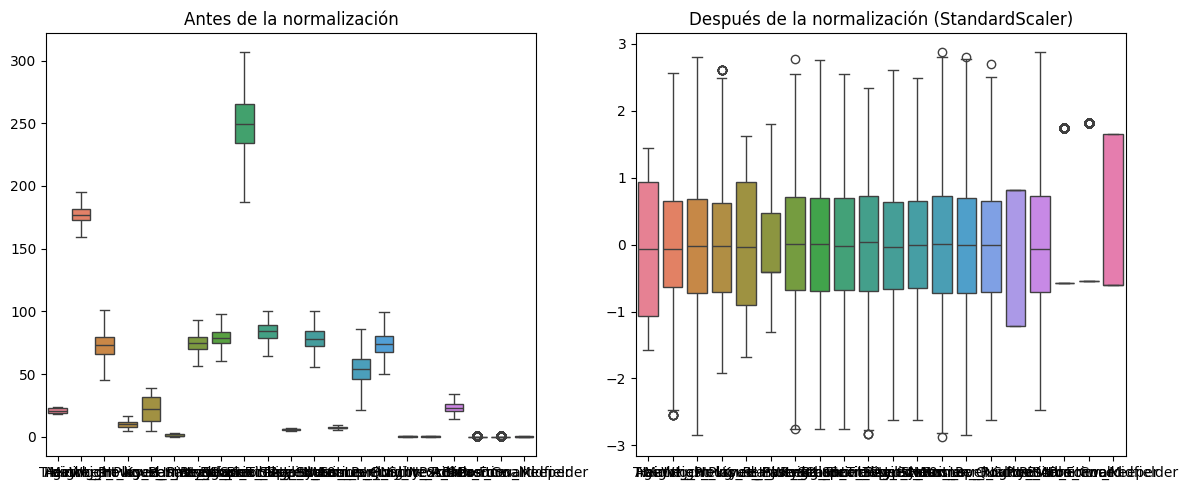

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df_encoded, ax=axes[0])
axes[0].set_title("Antes de la normalización")

sns.boxplot(data=df_scaled, ax=axes[1])
axes[1].set_title("Después de la normalización (StandardScaler)")

plt.tight_layout()
plt.show()

# 4. En caso de tener muchas características: aplicar un algoritmo de reducción de características como PCA, LDA, etc. (Decidir qué variables eliminar y explicar el por qué)

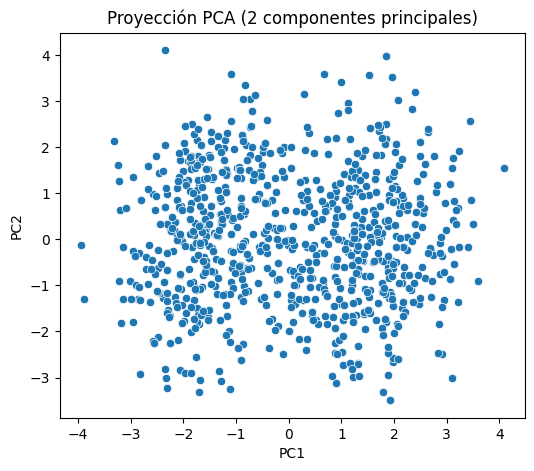

Varianza explicada por las componentes: [0.14690626 0.10043429]
Varianza total explicada: 0.24734055774369632


In [9]:
# Aplicar PCA a los datos normalizados
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)  # df_scaled: tu dataset normalizado

# Crear DataFrame con los resultados
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

# Visualización
plt.figure(figsize=(6,5))
sns.scatterplot(x='PC1', y='PC2', data=pca_df)
plt.title("Proyección PCA (2 componentes principales)")
plt.show()

# Varianza explicada
print("Varianza explicada por las componentes:", pca.explained_variance_ratio_)
print("Varianza total explicada:", pca.explained_variance_ratio_.sum())


### Justificacion
#### Dado que las dos primeras componentes solo explican el 27.3% de la varianza total, el PCA no aporta una reducción significativa de la dimensionalidad ni mejora la interpretación de los datos. Por tanto, no es recomendable aplicar PCA en este caso, ya que podría generar pérdida de información sin aportar ventajas al análisis. Se opta por mantener todas las variables originales, ya normalizadas, para preservar el detalle y la riqueza de la información en el modelado posterior.

# 5. Realizar un algormito de árbol de decisión, XGBoost, Regresión lineal con lasso, etc para seleccionar características posibles a eliminar

C:\Users\mejia\AppData\Local\Temp\ipykernel_5400\3664555567.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lasso_importances, x='Coeficiente', y='Variable', palette='coolwarm')


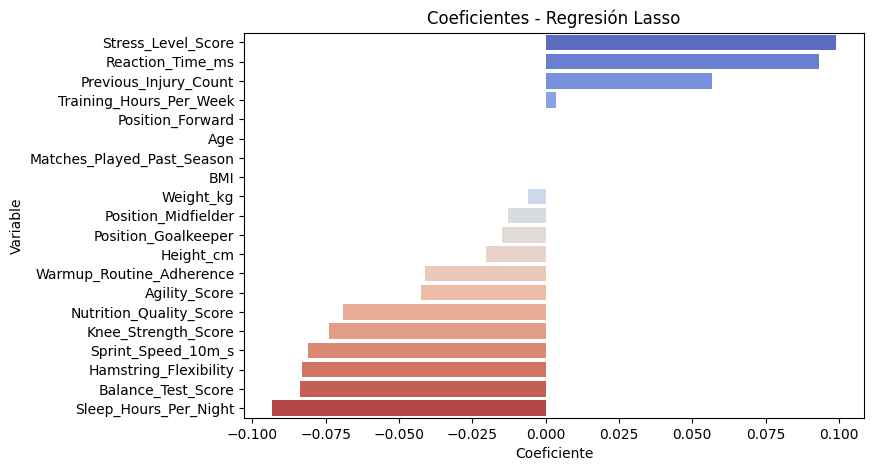

                      Variable  Coeficiente
13          Stress_Level_Score     0.099014
8             Reaction_Time_ms     0.093087
5        Previous_Injury_Count     0.056642
3      Training_Hours_Per_Week     0.003703
17            Position_Forward     0.000196
0                          Age     0.000000
4   Matches_Played_Past_Season     0.000000
16                         BMI    -0.000000
2                    Weight_kg    -0.005990
19         Position_Midfielder    -0.012916
18         Position_Goalkeeper    -0.014870
1                    Height_cm    -0.020338
15    Warmup_Routine_Adherence    -0.041249
11               Agility_Score    -0.042334
14     Nutrition_Quality_Score    -0.068989
6          Knee_Strength_Score    -0.073821
10          Sprint_Speed_10m_s    -0.080832
7        Hamstring_Flexibility    -0.083105
9           Balance_Test_Score    -0.083559
12       Sleep_Hours_Per_Night    -0.093140


In [10]:
# Entrenar modelo Lasso con validación cruzada
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(df_scaled, y)

# Coeficientes
lasso_importances = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lasso.coef_
}).sort_values(by='Coeficiente', ascending=False)

# Visualización
plt.figure(figsize=(8,5))
sns.barplot(data=lasso_importances, x='Coeficiente', y='Variable', palette='coolwarm')
plt.title("Coeficientes - Regresión Lasso")
plt.show()

print(lasso_importances)

### Justificacion
#### La regresión lineal con Lasso se utilizó para identificar las variables más relevantes en la predicción de Injury_Next_Season, aplicando una penalización que reduce el peso de aquellas con poca influencia. Entonces, se mantienen las variables con coeficientes altos (positivos o negativos) por su relevancia predictiva y se eliminan aquellos con valores cercanos a cero.

In [11]:
# Umbral para considerar un coeficiente "cercano a cero"
threshold = 0.01  # se puede ajustar entre 0.01 y 0.05 según el caso

# Identificar variables a eliminar
variables_a_eliminar = lasso_importances[
    lasso_importances['Coeficiente'].abs() < threshold
]['Variable'].tolist()

print("Variables a eliminar por baja relevancia:")
print(variables_a_eliminar)

# Crear nuevo DataFrame sin esas variables
X_reducido = X.drop(columns=variables_a_eliminar)

print("\nDimensiones del dataset original:", X.shape)
print("Dimensiones del dataset reducido:", X_reducido.shape)


Variables a eliminar por baja relevancia:
['Training_Hours_Per_Week', 'Position_Forward', 'Age', 'Matches_Played_Past_Season', 'BMI', 'Weight_kg']

Dimensiones del dataset original: (800, 20)
Dimensiones del dataset reducido: (800, 14)


In [12]:

ruta_datos = r"C:\Users\mejia\Desktop\Estudio\IA\Proyecto4-IA\Datos"

# =============================
# f) Separar Train - Test [80% - 20%]
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X_reducido, y, test_size=0.2, random_state=42, stratify=y
)

# =============================
# g) Separar el Train anterior en Train2 - Validation [80% - 20%]
# =============================
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# X_train: 64% del total
# X_val: 16% del total
# X_test: 20% del total

# =============================
# Guardar los 6 archivos CSV
# =============================
X_train2.to_csv(rf"{ruta_datos}\TrainX.csv", index=False)
y_train2.to_csv(rf"{ruta_datos}\TrainY.csv", index=False)

X_val.to_csv(rf"{ruta_datos}\ValidationX.csv", index=False)
y_val.to_csv(rf"{ruta_datos}\ValidationY.csv", index=False)

X_test.to_csv(rf"{ruta_datos}\TestX.csv", index=False)
y_test.to_csv(rf"{ruta_datos}\TestY.csv", index=False)

print("Archivos CSV guardados correctamente en:")
print(ruta_datos)

Archivos CSV guardados correctamente en:
C:\Users\mejia\Desktop\Estudio\IA\Proyecto4-IA\Datos
